In [21]:
import os
import warnings
from typing import Dict, List

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.colors import Normalize
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ファイル名は今までと同じ
PANEL_FILE = "panel_ibaraki_ssdse_with_W.csv"
SHAPEFILE  = "N03-20240101_08.shp"

print("=== Loading panel data ===")
panel = pd.read_csv(PANEL_FILE)
print("Panel shape:", panel.shape)
print(panel.head())

print("\n=== Loading shapefile ===")
gdf_shp = gpd.read_file(SHAPEFILE)
gdf_ibaraki = gdf_shp[gdf_shp["N03_001"] == "茨城県"].copy()

# 市町村ごとに dissolve
gdf_shp_dissolved = (
    gdf_ibaraki
    .dissolve(by="N03_004", as_index=False)
    .rename(columns={"N03_004": "city_name"})
)

print("gdf_shp_dissolved shape:", gdf_shp_dissolved.shape)
print(gdf_shp_dissolved[["city_name"]].head())

# ==========================================
# 設定（自分の環境に合わせて必要なら書き換える）
# ==========================================
PANEL_FILE = "panel_ibaraki_ssdse_with_W.csv"   # パネルデータ
SHAPEFILE  = "N03-20240101_08.shp"             # 行政区域のシェープファイル
NEIGH_FILE = "ibaraki_neighbors.csv"           # 既に作成した隣接リスト

# マップ用の年設定
LEVEL_YEAR    = 2020   # 絶対人口マップ
BASE_YEAR     = 2000   # 増減率の基準年
TARGET_YEAR   = 2020   # 増減率の比較年（実測）

FORECAST_YEARS = [2030, 2040]  # 予測したい年

# 地図にラベルを付ける市町村
LABEL_CITIES = ["水戸市", "つくば市", "日立市", "常陸太田市", "ひたちなか市", "古河市"]

# 日本語フォント（Windows想定）
plt.rcParams["font.family"] = "MS Gothic"


# ==========================================
# ユーティリティ
# ==========================================
def load_panel(path: str) -> pd.DataFrame:
    print("=== Loading panel data ===")
    df = pd.read_csv(path, encoding="utf-8-sig")
    print("Panel shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print(df.head())
    return df


def load_neighbors(path: str) -> Dict[str, List[str]]:
    print("\n=== Loading neighbor list ===")
    df = pd.read_csv(path, encoding="utf-8-sig")
    print("Neighbors shape:", df.shape)
    print(df.head())
    neigh_dict: Dict[str, List[str]] = {}
    for city, grp in df.groupby("city_name"):
        neigh_dict[city] = sorted(grp["neighbor_name"].unique().tolist())
    print("\nNeighbor dict sample:")
    for i, (k, v) in enumerate(neigh_dict.items()):
        print(" ", k, "->", v)
        if i >= 4:
            break
    return neigh_dict


def load_ibaraki_shapefile(path: str) -> gpd.GeoDataFrame:
    """
    国土数値情報 N03 から茨城県だけ抽出して city_name で dissolve する
    """
    print("\n=== Loading shapefile ===")
    gdf = gpd.read_file(path)
    print("Shapefile columns:", gdf.columns.tolist())

    # 茨城県だけ
    gdf_ibaraki = gdf[gdf["N03_001"] == "茨城県"].copy()
    print("Filtered to 茨城県:", len(gdf_ibaraki), "rows")

    gdf_ibaraki["city_name"] = (
        gdf_ibaraki["N03_004"]
        .astype(str)
        .str.replace("　", "")
        .str.strip()
    )

    # 市町村ごとにポリゴンをまとめる
    gdf_city = gdf_ibaraki.dissolve(by="city_name", as_index=False)
    print("After dissolve (one polygon per city):", len(gdf_city), "rows")
    print(gdf_city[["city_name"]].head())
    return gdf_city


def annotate_cities(ax, gdf_city: gpd.GeoDataFrame, label_cities: List[str]):
    """
    主要都市にラベルを付ける
    """
    gdf_lab = gdf_city[gdf_city["city_name"].isin(label_cities)].copy()
    # centroid は将来の GeoPandas では警告が出ることがあるので抑制
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        centroids = gdf_lab.geometry.centroid  # noqa: F841

    for _, row in gdf_lab.iterrows():
        city = row["city_name"]
        pt = row.geometry.centroid
        ax.text(
            pt.x, pt.y, city,
            fontsize=8, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6)
        )


# ==========================================
# 空間ラグ W * log_pop を作る関数（パネル用）
# ==========================================
def build_W_log_pop_lag1(panel: pd.DataFrame,
                         neigh_dict: Dict[str, List[str]]) -> pd.DataFrame:
    """
    panel には city_name, year, log_pop が入っている前提。
    各年 t について「前年 t-1 の近隣市町村の log_pop の平均」を
    W_log_pop_lag1 として計算する。
    """
    if "W_log_pop_lag1" in panel.columns:
        # 既に計算済みなら何もしない
        print("W_log_pop_lag1 は既に存在します。再計算はしません。")
        return panel

    print("\n=== Building W_log_pop_lag1 for panel ===")
    panel = panel.copy()
    panel["W_log_pop_lag1"] = np.nan

    years = sorted(panel["year"].unique())
    cities = sorted(panel["city_name"].unique())

    print("Years:", years)
    print("Cities:", cities)

    for t in years:
        prev_t = t - 1
        df_prev = panel[panel["year"] == prev_t][["city_name", "log_pop"]]
        if df_prev.empty:
            # 最初の年など、前年がない場合
            continue
        prev_map = df_prev.set_index("city_name")["log_pop"].to_dict()

        mask_t = panel["year"] == t
        idx_t = panel.index[mask_t]

        for idx in idx_t:
            city = panel.at[idx, "city_name"]
            neighs = neigh_dict.get(city, [])
            vals = [prev_map[nc] for nc in neighs if nc in prev_map]
            if len(vals) == 0:
                # 近隣がいない/見つからない場合は自市の前年比を使う（消極的対処）
                val = prev_map.get(city, np.nan)
            else:
                val = float(np.mean(vals))
            panel.at[idx, "W_log_pop_lag1"] = val

    print("Finished building W_log_pop_lag1.")
    return panel


# ==========================================
# 空間ラグ（ベクター版：将来予測に使う）
# ==========================================
def spatial_lag_from_vector(log_pop_series: pd.Series,
                            neigh_dict: Dict[str, List[str]]) -> pd.Series:
    """
    log_pop_series: index=city_name, value=log_pop
    から、近隣市町村の log_pop の平均を返す
    """
    result = {}
    for city, val in log_pop_series.items():
        neighs = neigh_dict.get(city, [])
        vals = [log_pop_series.get(nc) for nc in neighs if nc in log_pop_series.index]
        vals = [v for v in vals if pd.notna(v)]
        if len(vals) == 0:
            w_val = val  # 近隣がないときは自分自身を使う
        else:
            w_val = float(np.mean(vals))
        result[city] = w_val
    return pd.Series(result)


# ==========================================
# 時空間モデルの推定（AR(1)+W+SSDSE）
# ==========================================
def fit_spatial_model(panel, ssdse_cols):
    print("=== Fitting AR(1)+W+SSDSE model (for forecasting) ===")

    # 回帰に使う列をまとめて指定
    cols = [
        "log_pop",
        "log_pop_lag1",
        "W_log_pop_lag1",
        "share_under15",
        "share_over65",
        "nat_inc_rate",
        "soc_inc_rate",
        "A7101",
        "A710101",
    ]

    # この中で NaN or inf がある行を落とす
    df = panel[cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    print("Used rows for regression:", len(df))

    y = df["log_pop"]
    X = df[[
        "log_pop_lag1",
        "W_log_pop_lag1",
        "share_under15",
        "share_over65",
        "nat_inc_rate",
        "soc_inc_rate",
        "A7101",
        "A710101",
    ]]

    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    print(model.summary())

    return model
print("=== Fitting AR(1)+W+SSDSE model (for forecasting) ===")    
# どの SSDSE 変数を使うか
ssdse_cols = [
    "share_under15",
    "share_over65",
    "nat_inc_rate",
    "soc_inc_rate",
    "A7101",
    "A710101",
]

# 学習に使う年（例：2020年まで）
train_mask = panel["year"] <= 2020

# 必要な列だけ取り出して NaN 行を落とす
cols_needed = ["log_pop", "log_pop_lag1", "W_log_pop_lag1"] + ssdse_cols
train_df = panel.loc[train_mask, cols_needed].dropna()

# 目的変数と説明変数
y = train_df["log_pop"]
X = train_df[["log_pop_lag1", "W_log_pop_lag1"] + ssdse_cols]
X = sm.add_constant(X)

# 推定
model_ar_w_ssdse = sm.OLS(y, X).fit()
print(model_ar_w_ssdse.summary())
# ★ここが超重要★
model_ar_w_ssdse = sm.OLS(y, X).fit()

print(model_ar_w_ssdse.summary())

# 学習に使う年（例：2020年まで）
train_mask = panel["year"] <= 2020


print(model_ar_w_ssdse.summary())

cols_needed = ["log_pop", "log_pop_lag1", "W_log_pop_lag1"] + ssdse_cols
df = panel.dropna(subset=cols_needed).copy()

y = df["log_pop"].values
X = df[["log_pop_lag1", "W_log_pop_lag1"] + ssdse_cols]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())



# ==========================================
# 将来人口の予測（2030, 2040 など）
# ==========================================
def forecast_future(panel, neighbors_dict, model, ssdse_cols, forecast_years, base_year=2020):
    """
    base_year の人口と SSDSE 指標を使って、
    forecast_years に入っている年の log(pop) を予測する。
    """
    # 1) base_year の SSDSE 指標
    feat_df = (
        panel[panel["year"] == base_year]
        .copy()[["city_name"] + ssdse_cols]
        .drop_duplicates(subset="city_name")
        .set_index("city_name")
    )

    # 2) base_year の log(pop) を初期値として使用
    log_base = (
        panel[panel["year"] == base_year]
        .copy()[["city_name", "log_pop"]]
        .set_index("city_name")["log_pop"]
        .to_dict()
    )

    cities = list(feat_df.index)
    current_logs = log_base.copy()

    forecast_rows = []

    # 年ごとに1ステップずつ予測を進めていく想定
    max_year = max(forecast_years)
    for year in range(base_year + 1, max_year + 1):
        new_logs = {}

        for city in cities:
            log_pop_lag1 = current_logs[city]

            neighs = neighbors_dict.get(city, [])
            neigh_logs = [current_logs[n] for n in neighs if n in current_logs]
            if len(neigh_logs) > 0:
                W_log = np.mean(neigh_logs)
            else:
                W_log = log_pop_lag1

            feats = feat_df.loc[city, ssdse_cols]

            x_row = {
                "const": 1.0,
                "log_pop_lag1": log_pop_lag1,
                "W_log_pop_lag1": W_log,
            }
            for c in ssdse_cols:
                x_row[c] = feats[c]

            X_pred = pd.DataFrame([x_row])
            log_pred = model.predict(X_pred)[0]
            pop_pred = float(np.exp(log_pred))

            new_logs[city] = log_pred

            # この year が forecast_years に含まれているなら保存
            if year in forecast_years:
                forecast_rows.append(
                    {
                        "city_name": city,
                        "year": year,
                        "log_pop_pred": log_pred,
                        "pop_pred": pop_pred,
                    }
                )

        current_logs = new_logs

    return pd.DataFrame(forecast_rows)
# ==========================================
# マップ描画：人口レベル
# ==========================================
def make_level_map(panel: pd.DataFrame,
                   gdf_city: gpd.GeoDataFrame,
                   year: int,
                   out_png: str = None):
    print(f"\n=== Making population level map for {year} ===")
    df_year = panel[panel["year"] == year].copy()
    df_year = df_year.groupby("city_name", as_index=False)["population"].sum()

    gdf_merged = gdf_city.merge(df_year, on="city_name", how="left")
    missing = gdf_merged["population"].isna().sum()
    if missing > 0:
        print(f"Warning: {missing} polygons have NaN population for year={year}")

    # レンジを少しトリミング（外れ値対策）
    vmin = gdf_merged["population"].quantile(0.05)
    vmax = gdf_merged["population"].quantile(0.95)

    fig, ax = plt.subplots(figsize=(8, 8))
    gdf_merged.plot(
        column="population",
        ax=ax,
        cmap="OrRd",
        edgecolor="black",
        linewidth=0.3,
        legend=True,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"茨城県 市町村人口（{year}年）", fontsize=14)
    ax.axis("off")

    annotate_cities(ax, gdf_city, LABEL_CITIES)

    if out_png is None:
        out_png = f"map_pop_{year}.png"

    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    print("Saved:", out_png)
    plt.close(fig)


# ==========================================
# マップ描画：2時点増減率（実測）
# ==========================================
def make_growth_map(panel: pd.DataFrame,
                    gdf_city: gpd.GeoDataFrame,
                    base_year: int,
                    target_year: int,
                    out_png: str = None):
    print(f"\n=== Making growth map: {base_year} -> {target_year} ===")

    df_base = panel[panel["year"] == base_year][["city_name", "population"]]
    df_base = df_base.groupby("city_name", as_index=False)["population"].sum()
    df_base = df_base.rename(columns={"population": "pop_base"})

    df_target = panel[panel["year"] == target_year][["city_name", "population"]]
    df_target = df_target.groupby("city_name", as_index=False)["population"].sum()
    df_target = df_target.rename(columns={"population": "pop_target"})

    df = pd.merge(df_base, df_target, on="city_name", how="inner")
    df["growth_rate"] = (df["pop_target"] - df["pop_base"]) / df["pop_base"]

    gdf_merged = gdf_city.merge(df, on="city_name", how="left")
    missing = gdf_merged["growth_rate"].isna().sum()
    if missing > 0:
        print(f"Warning: {missing} polygons have NaN growth_rate for {base_year}->{target_year}")

    # 対称レンジ（%単位でわかりやすいように）
    vmin = gdf_merged["growth_rate"].quantile(0.05)
    vmax = gdf_merged["growth_rate"].quantile(0.95)
    absmax = max(abs(vmin), abs(vmax))

    fig, ax = plt.subplots(figsize=(8, 8))
    gdf_merged.plot(
        column="growth_rate",
        ax=ax,
        cmap="bwr",
        edgecolor="black",
        linewidth=0.3,
        legend=True,
        vmin=-absmax,
        vmax=absmax,
    )
    ax.set_title(f"茨城県 市町村人口増減率（{base_year}→{target_year}）", fontsize=14)
    ax.axis("off")

    annotate_cities(ax, gdf_city, LABEL_CITIES)

    if out_png is None:
        out_png = f"map_growth_{base_year}_{target_year}.png"

    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    print("Saved:", out_png)
    plt.close(fig)


# ==========================================
# マップ描画：予測値 vs 2020 年の増減率
# ==========================================
def make_forecast_growth_map(panel: pd.DataFrame,
                             df_pred: pd.DataFrame,
                             gdf_city: gpd.GeoDataFrame,
                             base_year: int,
                             forecast_year: int,
                             out_png: str = None):
    print(f"\n=== Making forecast growth map: {base_year} -> {forecast_year}_pred ===")

    df_base = panel[panel["year"] == base_year][["city_name", "population"]]
    df_base = df_base.groupby("city_name", as_index=False)["population"].sum()
    df_base = df_base.rename(columns={"population": "pop_base"})

    df_f = df_pred[df_pred["year"] == forecast_year][["city_name", "pop_pred"]].copy()
    df_f = df_f.rename(columns={"pop_pred": "pop_target"})

    df = pd.merge(df_base, df_f, on="city_name", how="inner")
    df["growth_rate"] = (df["pop_target"] - df["pop_base"]) / df["pop_base"]

    gdf_merged = gdf_city.merge(df, on="city_name", how="left")
    missing = gdf_merged["growth_rate"].isna().sum()
    if missing > 0:
        print(f"Warning: {missing} polygons have NaN forecast growth_rate for {base_year}->{forecast_year}")

    vmin = gdf_merged["growth_rate"].quantile(0.05)
    vmax = gdf_merged["growth_rate"].quantile(0.95)
    absmax = max(abs(vmin), abs(vmax))

    fig, ax = plt.subplots(figsize=(8, 8))
    gdf_merged.plot(
        column="growth_rate",
        ax=ax,
        cmap="bwr",
        edgecolor="black",
        linewidth=0.3,
        legend=True,
        vmin=-absmax,
        vmax=absmax,
    )
    ax.set_title(f"人口増減率予測（{base_year}→{forecast_year}予測）", fontsize=14)
    ax.axis("off")

    annotate_cities(ax, gdf_city, LABEL_CITIES)

    if out_png is None:
        out_png = f"map_growth_{base_year}_{forecast_year}_pred.png"

    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    print("Saved:", out_png)
    plt.close(fig)


# ==========================================
# マップ描画：自然増減率・社会増減率のクラス分類
# ==========================================
def classify_rate(rate: float, kind: str = "nat") -> str:
    """
    rate: 一人当たり増減率（例えば nat_inc_rate）
    kind: "nat" or "soc" （ラベル用）
    """
    if pd.isna(rate):
        return "データなし"
    # 閾値は適当に決めているので、必要なら調整
    if rate <= -0.015:
        base = "減少（大）"
    elif rate <= -0.007:
        base = "減少（中）"
    elif rate <= -0.002:
        base = "減少（小）"
    elif rate < 0.002:
        base = "ほぼ横ばい"
    elif rate < 0.007:
        base = "増加（小）"
    else:
        base = "増加（大）"

    if kind == "nat":
        return "自然" + base
    else:
        return "社会" + base


def make_rate_class_map(panel: pd.DataFrame,
                        gdf_city: gpd.GeoDataFrame,
                        rate_col: str,
                        kind: str,
                        out_png: str = None):
    """
    rate_col: "nat_inc_rate" or "soc_inc_rate"
    kind: "nat" or "soc"
    """
    label = "自然増減率" if kind == "nat" else "社会増減率"

    print(f"\n=== Making {label} class map ({rate_col}) ===")

    # city 単位にまとめる（時間不変とみなして平均）
    df_rate = (
        panel.groupby("city_name")[rate_col]
        .mean()
        .reset_index()
    )
    df_rate["rate_cat"] = df_rate[rate_col].apply(lambda r: classify_rate(r, kind=kind))

    gdf_merged = gdf_city.merge(df_rate, on="city_name", how="left")

    # カテゴリごとの色
    color_map = {
        "自然減少（大）": "#542788",
        "自然減少（中）": "#998ec3",
        "自然減少（小）": "#d8daeb",
        "自然ほぼ横ばい": "#f7f7f7",
        "自然増加（小）": "#a6dba0",
        "自然増加（大）": "#1b7837",
        "社会減少（大）": "#b2182b",
        "社会減少（中）": "#ef8a62",
        "社会減少（小）": "#fddbc7",
        "社会ほぼ横ばい": "#f7f7f7",
        "社会増加（小）": "#d1e5f0",
        "社会増加（大）": "#2166ac",
        "データなし": "#cccccc",
    }

    fig, ax = plt.subplots(figsize=(8, 8))

    # GeoPandas の categorical plot を自前 legend で描く
    for cat, sub in gdf_merged.groupby("rate_cat"):
        color = color_map.get(cat, "#cccccc")
        sub.plot(ax=ax, color=color, edgecolor="black", linewidth=0.3, label=cat)

    ax.set_title(f"茨城県 市町村{label}クラス", fontsize=14)
    ax.axis("off")

    annotate_cities(ax, gdf_city, LABEL_CITIES)

    # 凡例（重複ラベルをまとめる）
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(), by_label.keys(),
        loc="lower left", bbox_to_anchor=(1.02, 0.1),
        fontsize=8, frameon=True
    )

    if out_png is None:
        out_png = f"map_{rate_col}_class.png"

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    print("Saved:", out_png)
    plt.close(fig)


# ==========================================
# main
# ==========================================
def main():
    # データ存在チェック
    if not os.path.exists(PANEL_FILE):
        raise FileNotFoundError(f"{PANEL_FILE} が見つかりません。")
    if not os.path.exists(SHAPEFILE):
        raise FileNotFoundError(f"{SHAPEFILE} が見つかりません。")
    if not os.path.exists(NEIGH_FILE):
        raise FileNotFoundError(f"{NEIGH_FILE} が見つかりません。")

    # 1) データ読み込み
    panel = load_panel(PANEL_FILE)
    neigh_dict = load_neighbors(NEIGH_FILE)
    gdf_city = load_ibaraki_shapefile(SHAPEFILE)

    # 2) 必要なら W_log_pop_lag1 を作る
    panel = build_W_log_pop_lag1(panel, neigh_dict)

    # 3) ベースのマップ（実測）
    make_level_map(panel, gdf_city, year=LEVEL_YEAR)
    make_growth_map(panel, gdf_city, base_year=BASE_YEAR, target_year=TARGET_YEAR)

    # 4) 自然増減率・社会増減率のクラス別マップ
    if "nat_inc_rate" in panel.columns and "soc_inc_rate" in panel.columns:
        make_rate_class_map(panel, gdf_city, rate_col="nat_inc_rate", kind="nat")
        make_rate_class_map(panel, gdf_city, rate_col="soc_inc_rate", kind="soc")
    else:
        print("nat_inc_rate / soc_inc_rate が panel に無いので、そのマップはスキップします。")

    # 5) 時空間モデルを使った将来予測
    ssdse_cols = ["share_under15", "share_over65", "nat_inc_rate", "soc_inc_rate", "A7101", "A710101"]
    for c in ssdse_cols:
        if c not in panel.columns:
            raise KeyError(f"{c} が panel に存在しません。事前に作成してください。")

    model = fit_spatial_model(panel, ssdse_cols=ssdse_cols)
    df_pred = forecast_future(panel, neigh_dict, model, ssdse_cols, forecast_years=FORECAST_YEARS)

    # 6) 予測値 vs 2020 の増減率マップ
    for fy in FORECAST_YEARS:
        make_forecast_growth_map(panel, df_pred, gdf_city,
                                 base_year=TARGET_YEAR, forecast_year=fy)

    print("\n=== ALL DONE ===")


if __name__ == "__main__":
    main()

=== Loading panel data ===
Panel shape: (2068, 23)
  city_name  year  population    log_pop  log_pop_lag1  city_code   A1301  \
0   かすみがうら市  1976     36119.0  10.494574     10.485312        NaN  4376.0   
1   かすみがうら市  1977     36736.0  10.511512     10.494574        NaN  4376.0   
2   かすみがうら市  1978     37387.0  10.529078     10.511512        NaN  4376.0   
3   かすみがうら市  1979     37919.0  10.543208     10.529078        NaN  4376.0   
4   かすみがうら市  1980     38797.0  10.566098     10.543208        NaN  4376.0   

     A1302    A1303  A4101  ...    A7101  A710101  share_under15  \
0  22859.0  12779.0  176.0  ...  15271.0  15230.0       0.121155   
1  22859.0  12779.0  176.0  ...  15271.0  15230.0       0.119120   
2  22859.0  12779.0  176.0  ...  15271.0  15230.0       0.117046   
3  22859.0  12779.0  176.0  ...  15271.0  15230.0       0.115404   
4  22859.0  12779.0  176.0  ...  15271.0  15230.0       0.112792   

   share_over65  birth_rate  death_rate  net_mig_rate  nat_inc_rate  \
0     

C:\Users\johns\AppData\Local\Temp\ipykernel_23096\2293633001.py:610: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()


Saved: map_nat_inc_rate_class.png

=== Making 社会増減率 class map (soc_inc_rate) ===


C:\Users\johns\AppData\Local\Temp\ipykernel_23096\2293633001.py:610: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()


Saved: map_soc_inc_rate_class.png
=== Fitting AR(1)+W+SSDSE model (for forecasting) ===
Used rows for regression: 1936
                            OLS Regression Results                            
Dep. Variable:                log_pop   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.176e+05
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               0.00
Time:                        07:30:08   Log-Likelihood:                 5246.3
No. Observations:                1936   AIC:                        -1.047e+04
Df Residuals:                    1927   BIC:                        -1.042e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------

In [22]:
# ===== 4象限分類マップ（自然増減率 × 社会増減率） =====
forecast_df = pd.read_csv("forecast_result.csv", encoding="utf-8-sig")
BASE_YEAR = 2020  # どの年の nat/soc を使うか

# 1) 2020年の自然増減率・社会増減率を city 単位にまとめる
df_rate = (
    panel[panel["year"] == BASE_YEAR]
    .copy()[["city_name", "nat_inc_rate", "soc_inc_rate"]]
    .drop_duplicates(subset="city_name")
)

def classify_quad(row, th_nat=0.0, th_soc=0.0):
    nat = row["nat_inc_rate"]
    soc = row["soc_inc_rate"]
    if nat < th_nat and soc < th_soc:
        return "自然減 × 社会減"
    elif nat < th_nat and soc >= th_soc:
        return "自然減 × 社会増"
    elif nat >= th_nat and soc < th_soc:
        return "自然増 × 社会減"
    else:
        return "自然増 × 社会増"

df_rate["quad"] = df_rate.apply(classify_quad, axis=1)

# 3) 地図と結合
gdf_city = gdf_shp_dissolved.copy()
gdf_quad = gdf_city.merge(df_rate, on="city_name", how="left")

# 4) 色分け用マップ
quad2color = {
    "自然減 × 社会減": "#d73027",  # 赤
    "自然減 × 社会増": "#fc8d59",  # オレンジ
    "自然増 × 社会減": "#4575b4",  # 青
    "自然増 × 社会増": "#1a9850",  # 緑
}
gdf_quad["color"] = gdf_quad["quad"].map(quad2color)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_quad.plot(color=gdf_quad["color"], edgecolor="black", linewidth=0.5, ax=ax)

# 凡例
for label, color in quad2color.items():
    ax.scatter([], [], color=color, label=label)
ax.legend(loc="lower left", fontsize=9, frameon=True)

ax.set_title(f"自然増減率 × 社会増減率（{BASE_YEAR}年）4象限分類", fontproperties=None)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f"map_nat_soc_quad_{BASE_YEAR}.png", dpi=300)
plt.close()

print(f"Saved: map_nat_soc_quad_{BASE_YEAR}.png")

Saved: map_nat_soc_quad_2020.png


In [23]:
# ==========================================
# 増減率ランキング表 2000→2020 / 2020→2030 / 2020→2040
# ==========================================


# 1) 実績：2000→2020
pop_2000 = panel[panel["year"] == 2000][["city_name", "population"]].set_index("city_name")
pop_2020 = panel[panel["year"] == 2020][["city_name", "population"]].set_index("city_name")

df_growth_00_20 = pop_2000.join(pop_2020, how="inner", lsuffix="_2000", rsuffix="_2020")
df_growth_00_20["growth_rate_00_20"] = df_growth_00_20["population_2020"] / df_growth_00_20["population_2000"] - 1

# 2) 予測：2020→2030 / 2020→2040
# forecast_df は、「Forecast result (head): ...」って出ていた DataFrame を想定
pop_2030 = forecast_df[forecast_df["year"] == 2030][["city_name", "pop_pred"]].set_index("city_name")
pop_2040 = forecast_df[forecast_df["year"] == 2040][["city_name", "pop_pred"]].set_index("city_name")

df_growth_20_30 = pop_2020.join(pop_2030, how="inner")
df_growth_20_30.columns = ["pop_2020", "pop_2030"]
df_growth_20_30["growth_rate_20_30"] = df_growth_20_30["pop_2030"] / df_growth_20_30["pop_2020"] - 1

df_growth_20_40 = pop_2020.join(pop_2040, how="inner")
df_growth_20_40.columns = ["pop_2020", "pop_2040"]
df_growth_20_40["growth_rate_20_40"] = df_growth_20_40["pop_2040"] / df_growth_20_40["pop_2020"] - 1


def print_rank(df, col, label):
    print(f"\n=== {label} 増減率ランキング ===")
    # Top 3
    top3 = df.sort_values(col, ascending=False).head(3).copy()
    bottom3 = df.sort_values(col, ascending=True).head(3).copy()

    print("\n  上位3市町村（増加が大きい）")
    for name, row in top3.iterrows():
        print(f"   {name}: {row[col]:.1%}")

    print("\n  下位3市町村（減少が大きい）")
    for name, row in bottom3.iterrows():
        print(f"   {name}: {row[col]:.1%}")


print_rank(df_growth_00_20, "growth_rate_00_20", "2000→2020（実績）")
print_rank(df_growth_20_30, "growth_rate_20_30", "2020→2030（予測）")
print_rank(df_growth_20_40, "growth_rate_20_40", "2020→2040（予測）")

# 論文用に全部のランキングを CSV にしておく
df_growth_00_20.sort_values("growth_rate_00_20", ascending=False).to_csv(
    "rank_growth_2000_2020.csv", encoding="utf-8-sig"
)
df_growth_20_30.sort_values("growth_rate_20_30", ascending=False).to_csv(
    "rank_growth_2020_2030_pred.csv", encoding="utf-8-sig"
)
df_growth_20_40.sort_values("growth_rate_20_40", ascending=False).to_csv(
    "rank_growth_2020_2040_pred.csv", encoding="utf-8-sig"
)



=== 2000→2020（実績） 増減率ランキング ===

  上位3市町村（増加が大きい）
   守谷市: 35.9%
   つくば市: 26.0%
   つくばみらい市: 23.0%

  下位3市町村（減少が大きい）
   大子町: -34.4%
   河内町: -28.4%
   稲敷市: -23.9%

=== 2020→2030（予測） 増減率ランキング ===

  上位3市町村（増加が大きい）
   利根町: 1.5%
   美浦村: 1.1%
   守谷市: 1.0%

  下位3市町村（減少が大きい）
   桜川市: -0.8%
   河内町: -0.4%
   城里町: -0.4%

=== 2020→2040（予測） 増減率ランキング ===

  上位3市町村（増加が大きい）
   利根町: 3.0%
   美浦村: 2.1%
   守谷市: 2.0%

  下位3市町村（減少が大きい）
   桜川市: -1.6%
   河内町: -0.9%
   城里町: -0.8%



2040年に人口1万人未満と予測される市町村数： 2
市町村名リスト：
['五霞町', '河内町']


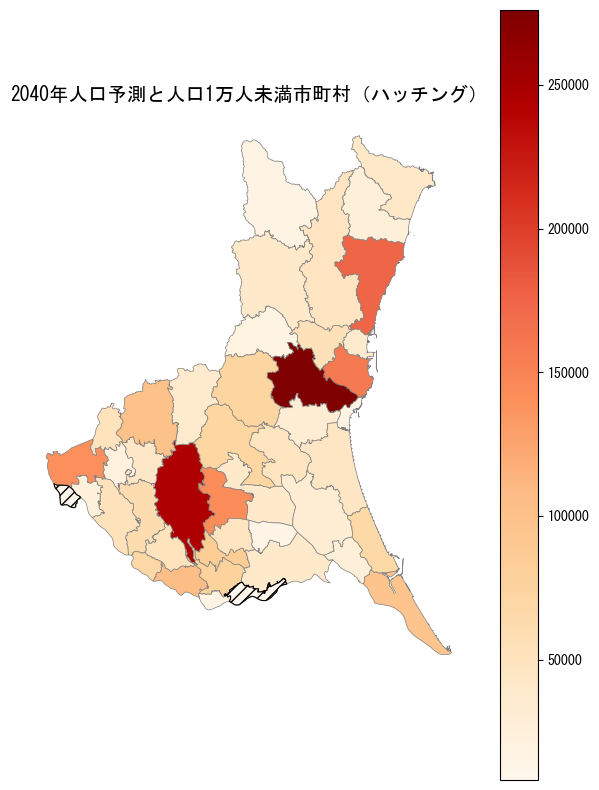

In [24]:
# ==========================================
# 2040年に人口1万人未満となる市町村のハッチングマップ
# ==========================================
forecast_df = pd.read_csv("forecast_result.csv", encoding="utf-8-sig")
THRESHOLD = 10000  # 閾値（人）

# さっき作った df_growth_20_40 を使う（pop_2040 列あり）
df_future = df_growth_20_40.copy()

# city_name を列に戻す
df_future = df_future.reset_index()

# 1万人未満フラグ
df_future["lt10k_2040"] = df_future["pop_2040"] < THRESHOLD

print("\n2040年に人口1万人未満と予測される市町村数：", df_future["lt10k_2040"].sum())
print("市町村名リスト：")
print(df_future.loc[df_future["lt10k_2040"], "city_name"].tolist())

# GeoDataFrame に結合
gdf_future = gdf_shp_dissolved.merge(
    df_future[["city_name", "pop_2040", "lt10k_2040"]],
    on="city_name",
    how="left"
)

fig, ax = plt.subplots(figsize=(6, 8))

# 背景として 2040年人口を塗る
base = gdf_future.plot(
    column="pop_2040",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="gray",
    legend=True,
    ax=ax,
)
ax.set_title("2040年人口予測と人口1万人未満市町村（ハッチング）", fontsize=14)

# 1万人未満のところにハッチング
gdf_future[gdf_future["lt10k_2040"]].plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.8,
    hatch="///",
)

ax.set_axis_off()

# ラベル付けしたければここで
# label_some_cities(ax, gdf_future, ["水戸市", "つくば市", ...])

plt.tight_layout()
plt.savefig("map_pop2040_lt10k_hatch.png", dpi=300, bbox_inches="tight")
plt.show()


In [25]:
# === 茨城県 全市町村が shapefile で取れているか確認するセル ===

print("=== パネル側（panel）に含まれる市町村 ===")
cities_panel = sorted(panel["city_name"].unique())
print(f"panel の市町村数: {len(cities_panel)}")
print(cities_panel)

print("\n=== 図形側（gdf_city）に含まれる市町村 ===")
cities_gdf = sorted(gdf_city["city_name"].unique())
print(f"gdf_city の市町村数: {len(cities_gdf)}")
print(cities_gdf)

set_panel = set(cities_panel)
set_gdf   = set(cities_gdf)

print("\n=== 差分チェック ===")
missing_in_gdf = set_panel - set_gdf
missing_in_panel = set_gdf - set_panel

if len(missing_in_gdf) == 0 and len(missing_in_panel) == 0:
    print("✅ パネルと shapefile の市町村名は完全一致しています。")
else:
    print("⚠ 一致していない市町村があります。")

    if missing_in_gdf:
        print("\nshapefile 側に存在しない（= gdf_city に無い）市町村:")
        for c in sorted(missing_in_gdf):
            print("  -", c)

    if missing_in_panel:
        print("\nパネル側に存在しない（= panel に無い）市町村:")
        for c in sorted(missing_in_panel):
            print("  -", c)


=== パネル側（panel）に含まれる市町村 ===
panel の市町村数: 44
['かすみがうら市', 'つくばみらい市', 'つくば市', 'ひたちなか市', '下妻市', '五霞町', '八千代町', '利根町', '北茨城市', '取手市', '古河市', '土浦市', '坂東市', '城里町', '境町', '大子町', '大洗町', '守谷市', '小美玉市', '常総市', '常陸大宮市', '常陸太田市', '日立市', '東海村', '桜川市', '水戸市', '河内町', '潮来市', '牛久市', '石岡市', '神栖市', '稲敷市', '笠間市', '筑西市', '結城市', '美浦村', '茨城町', '行方市', '那珂市', '鉾田市', '阿見町', '高萩市', '鹿嶋市', '龍ケ崎市']

=== 図形側（gdf_city）に含まれる市町村 ===
gdf_city の市町村数: 44
['かすみがうら市', 'つくばみらい市', 'つくば市', 'ひたちなか市', '下妻市', '五霞町', '八千代町', '利根町', '北茨城市', '取手市', '古河市', '土浦市', '坂東市', '城里町', '境町', '大子町', '大洗町', '守谷市', '小美玉市', '常総市', '常陸大宮市', '常陸太田市', '日立市', '東海村', '桜川市', '水戸市', '河内町', '潮来市', '牛久市', '石岡市', '神栖市', '稲敷市', '笠間市', '筑西市', '結城市', '美浦村', '茨城町', '行方市', '那珂市', '鉾田市', '阿見町', '高萩市', '鹿嶋市', '龍ケ崎市']

=== 差分チェック ===
✅ パネルと shapefile の市町村名は完全一致しています。
